<!-- Codex test: first cell touched -->
This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [0]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-10-02 16:01:49.770244: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-02 16:01:50.620043: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

Load shendure ortho object.

In [2]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [12]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

Let's make some plots showing why we chose nb:

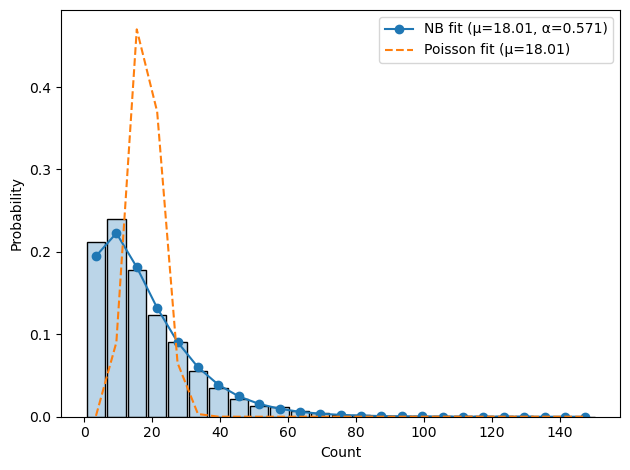

In [4]:
shendure_bounds.transfection_model.plot()

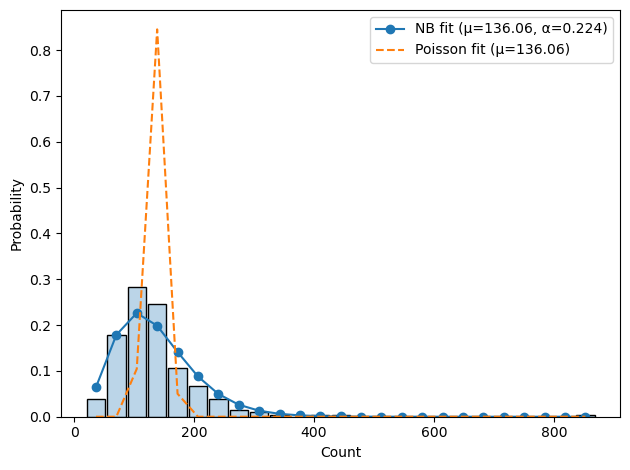

In [5]:
shendure_bounds.library_model.plot()

Now we check 

In [36]:
total_uniq_mpra_bc=primordial.training_data.data["mpra_bc"].nunique()
tfection=primordial.training_data.data.groupby(["rep_id","cell_bc"])["mpra_bc"].nunique().reset_index()
tfection=tfection.rename({"mpra_bc":"unique_mpra_bc"},axis=1)
observed=tfection["unique_mpra_bc"]
tfection["tot_plasmid"]=np.log(1-observed/total_uniq_mpra_bc)/np.log((total_uniq_mpra_bc-1)/total_uniq_mpra_bc)

total_tfection=tfection['tot_plasmid'].sum()

excess=total_tfection-tfection["unique_mpra_bc"].sum()
print(f"a total of {excess} estimated collision events, out of a total of {total_tfection}, or {excess/total_tfection*100}%")

a total of 414.7088384600356 estimated collision events, out of a total of 781874.70883846, or 0.05304031883524153%


In [15]:
import numpy as np
def retrospective_overtransfection_check(self):
    """
    
    """
   

retrospective_overtransfection_check(shendure_bounds)

array([-0.        ,  1.        ,  2.00003534,  3.00010602,  4.00021204,
        5.0003534 ,  6.00053011,  7.00074218,  8.00098959,  9.00127236])

In [7]:
dir(shendure_bounds.library_model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'adjust_nb',
 'alpha_nb',
 'data',
 'draw_nb',
 'from_data',
 'from_dataframe',
 'mu_nb',
 'mu_pois',
 'original_fit',
 'p',
 'plot',
 'r',
 'to_dataframe',
 'update_alt_nb_param']

Now let's save the object:

In [6]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [7]:
cluster.close()

2025-09-01 12:51:42,760 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:35303' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-ec46918b8639c956ebc32d52c0c3824f', 'lambda-1f636852c40baebbe80cb80c0a4baf8c', 'lambda-82cedd321ddf26236af3cc66bc3f8406', 'lambda-fa1872e07d8f80edab8a599178d94da1', 'lambda-77c13c09b0595652e96a6001f473ce87', 'lambda-55166f206a4caa40c15c026184e6bc20', 'lambda-b8aa453a917dfb55b84903dd802a5f59', 'lambda-bddaa07528489229065ba008d378bbd1', 'lambda-c48efed3b03d5da8488fba3ba0fd33b3', 'lambda-022f02acb24a28e83c1f8bcf6348b060', 'lambda-b70a640ec3639b1c76e7b8a123d0c800', 'lambda-112013e65d064cdb9fac4bcc3f768a09', 'lambda-144ca969a31dd8d2792030b2f57489b6', 'lambda-30060a8ae93d2acca46e4ca292aabaa3', 'lambda-a1ff96fdaff8b931087d6c02e152cb32', 'lambda-a906ea9c95de54541087d2bfa8f2505c', 'lambda-187c054622576b7840ca401c5d70820f', 'lambda-7480cb5fb9264927be7519d342d90b70', 'lambda-7c0b236babcddbe0df37b771d62c